# IEEE-CIS Fraud Detection — EDA, Outlier Analysis, Hypothesis Testing & Baseline Model
Dataset: IEEE-CIS Fraud Detection (Kaggle)

This notebook performs:
- Data Quality Assessment
- Fraud Distribution Analysis
- Feature Correlation Analysis
- Outlier Detection
- Hypothesis Testing
- Baseline Fraud Detection Model


In [ ]:
# Install dependencies if needed
# !pip install pandas numpy matplotlib seaborn scikit-learn lightgbm scipy umap-learn


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import mannwhitneyu, chi2_contingency, ks_2samp
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score, precision_recall_curve, roc_curve
from sklearn.metrics import classification_report, confusion_matrix
import lightgbm as lgb


## Load Dataset

In [2]:
transaction = pd.read_csv("train_transaction.csv")
identity = pd.read_csv("train_identity.csv")

df = transaction.merge(identity, on="TransactionID", how="left")

print(df.shape)
df.head()


(590540, 434)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


## Data Quality Assessment

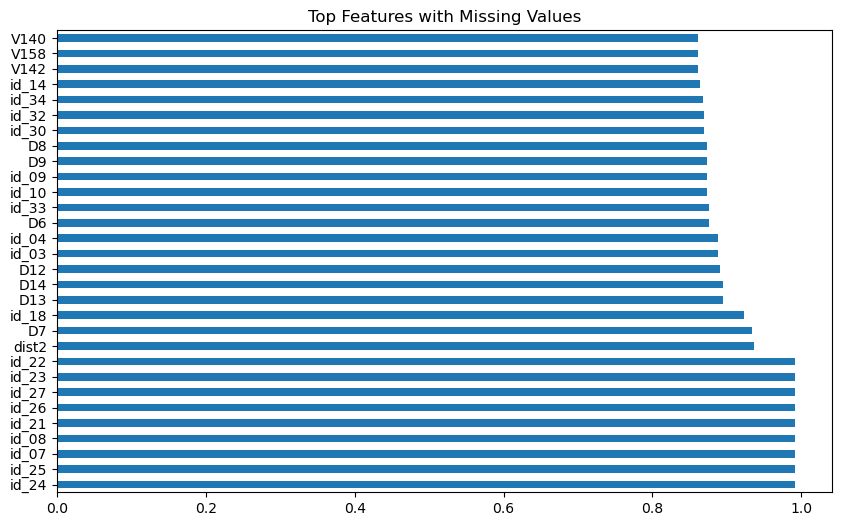

In [3]:
missing_ratio = df.isnull().mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
missing_ratio.head(30).plot(kind='barh')
plt.title("Top Features with Missing Values")
plt.show()


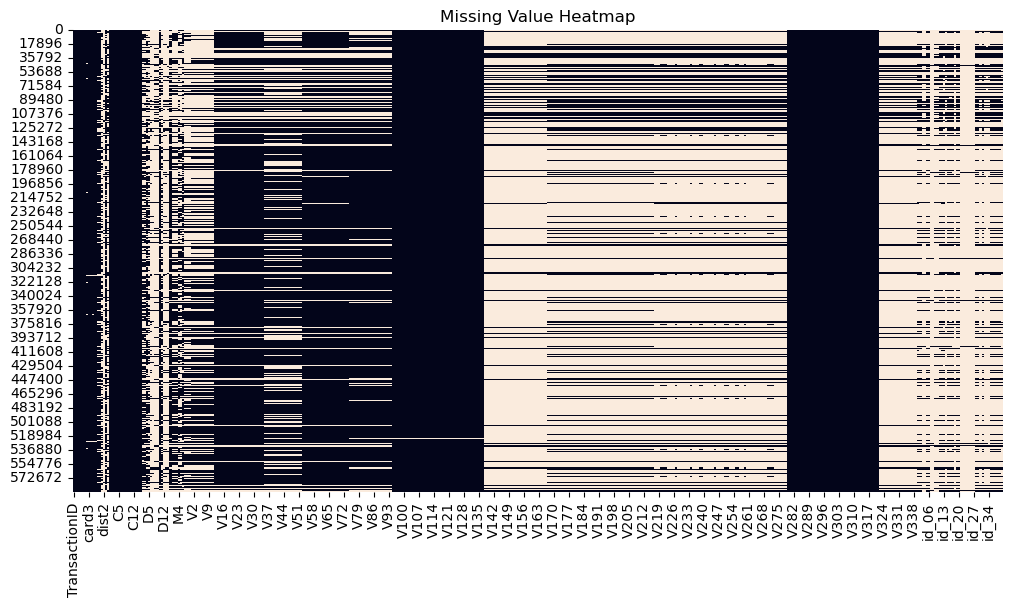

In [4]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Value Heatmap")
plt.show()


In [5]:
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)


Duplicate rows: 0


## Fraud Distribution Analysis

Fraud rate: 0.03499000914417313


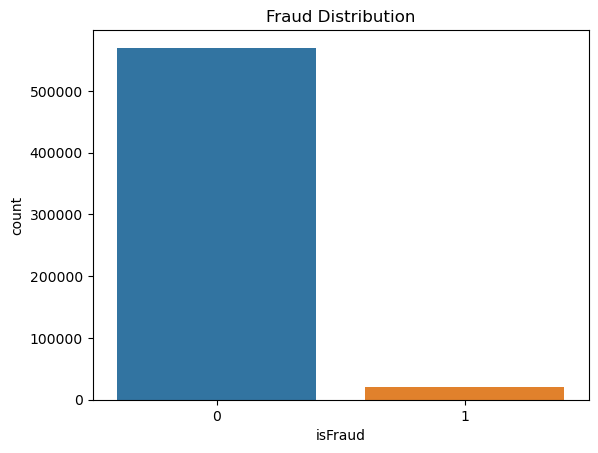

In [6]:
fraud_rate = df['isFraud'].mean()
print("Fraud rate:", fraud_rate)

sns.countplot(x="isFraud", data=df)
plt.title("Fraud Distribution")
plt.show()


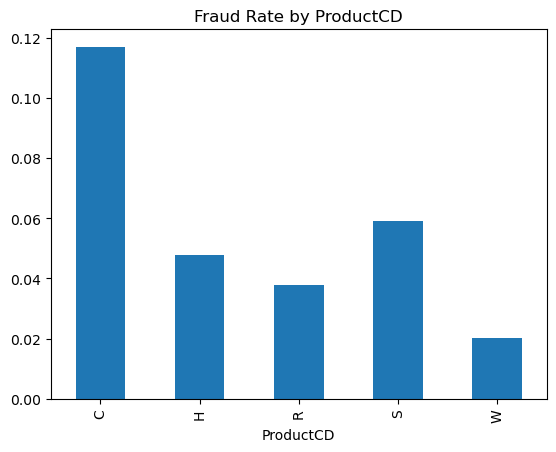

In [7]:
df.groupby("ProductCD")["isFraud"].mean().plot(kind="bar")
plt.title("Fraud Rate by ProductCD")
plt.show()


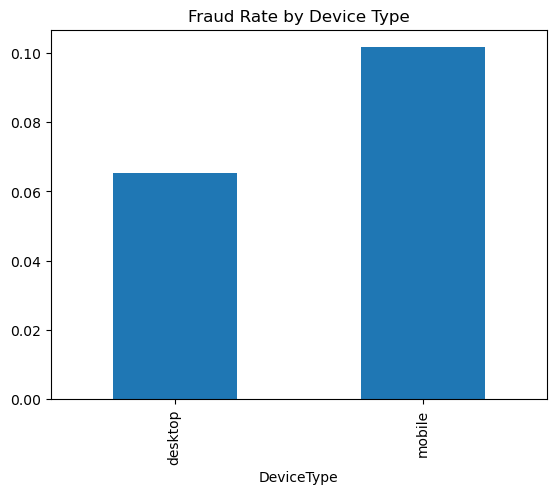

In [8]:
df.groupby("DeviceType")["isFraud"].mean().plot(kind="bar")
plt.title("Fraud Rate by Device Type")
plt.show()


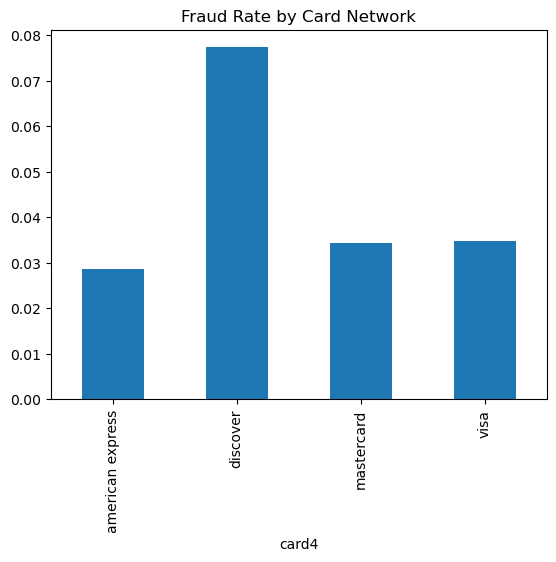

In [9]:
df.groupby("card4")["isFraud"].mean().plot(kind="bar")
plt.title("Fraud Rate by Card Network")
plt.show()


## Temporal Analysis

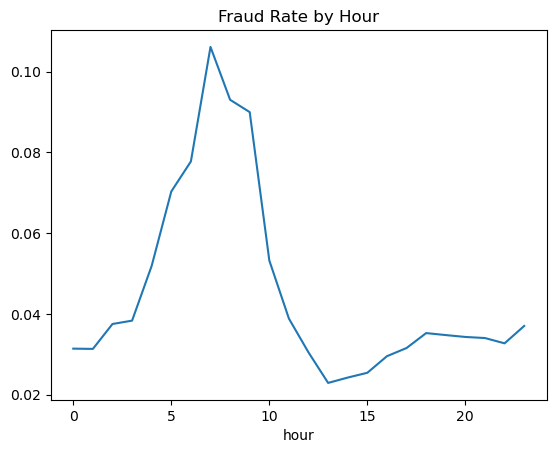

In [15]:
df["hour"] = ((df["TransactionDT"] // 3600) % 24).astype(int)
df["day"] = ((df["TransactionDT"] // 86400) % 7).astype(int)

df = df.dropna(subset=["hour","day"])
df.groupby("hour")["isFraud"].mean().plot()
plt.title("Fraud Rate by Hour")
plt.show()


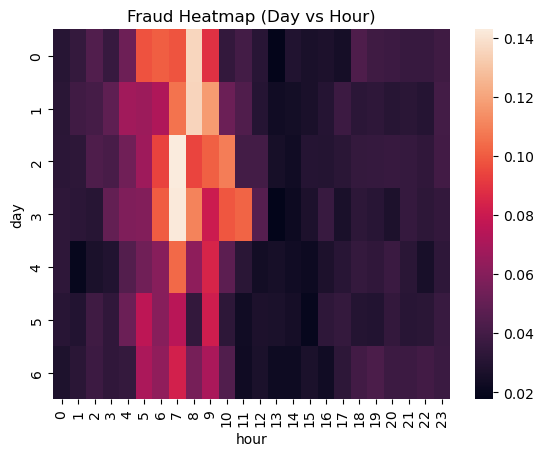

In [16]:
pivot = df.pivot_table(values="isFraud", index="day", columns="hour")

sns.heatmap(pivot)
plt.title("Fraud Heatmap (Day vs Hour)")
plt.show()


## Transaction Amount Distribution

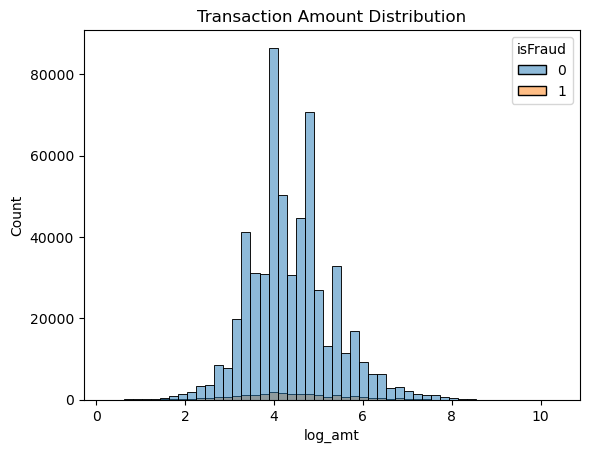

In [17]:
df["log_amt"] = np.log1p(df["TransactionAmt"])

sns.histplot(data=df, x="log_amt", hue="isFraud", bins=50)
plt.title("Transaction Amount Distribution")
plt.show()


In [18]:
fraud_amt = df[df.isFraud==1]["TransactionAmt"]
legit_amt = df[df.isFraud==0]["TransactionAmt"]

ks_stat, ks_p = ks_2samp(fraud_amt, legit_amt)
print("KS p-value:", ks_p)

u_stat, p_value = mannwhitneyu(fraud_amt, legit_amt)
print("Mann Whitney p:", p_value)


KS p-value: 1.0922930615278305e-99
Mann Whitney p: 0.22590783497976064


## Feature Correlation Analysis

In [21]:
numeric_df = df.select_dtypes(include=[np.number]).fillna(0)

numeric_df = numeric_df.loc[:, numeric_df.var() > 0]

sample_df = numeric_df.sample(100000, random_state=42)

X = sample_df.drop("isFraud", axis=1)
y = sample_df["isFraud"]

rf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X.columns)

top50 = importances.sort_values(ascending=False).head(50).index

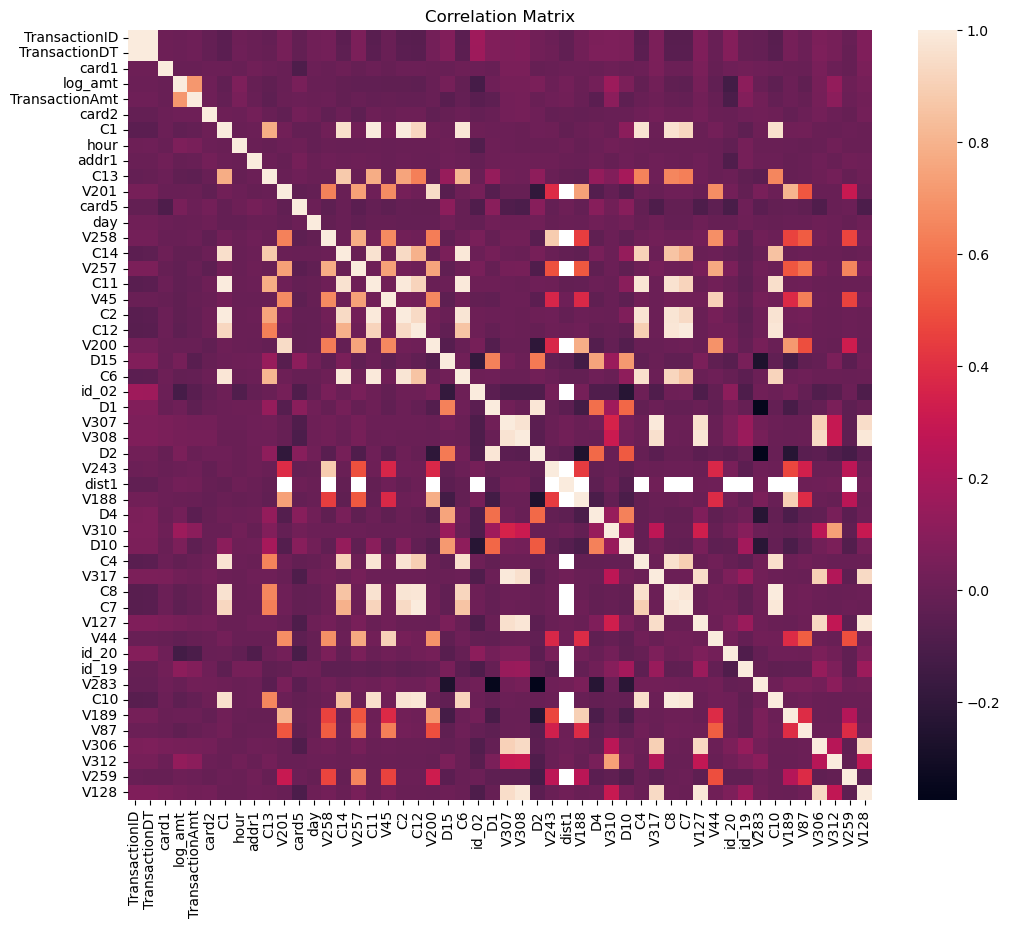

In [22]:
corr = df[top50].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr)
plt.title("Correlation Matrix")
plt.show()


## Outlier Detection

In [23]:
Q1 = df["TransactionAmt"].quantile(0.25)
Q3 = df["TransactionAmt"].quantile(0.75)

IQR = Q3 - Q1

iqr_outliers = df[(df["TransactionAmt"] < Q1 - 1.5*IQR) | 
                  (df["TransactionAmt"] > Q3 + 1.5*IQR)]

print("IQR Outliers:", len(iqr_outliers))


IQR Outliers: 66482


In [24]:
iso = IsolationForest(contamination=0.01)

df["iso_outlier"] = iso.fit_predict(df[["TransactionAmt"]].fillna(0))


In [26]:
features = ["TransactionAmt"] + [f"C{i}" for i in range(1,15)]

X = df[features].fillna(0)

lof = LocalOutlierFactor(
    n_neighbors=50,
    contamination=0.01,
    n_jobs=-1
)

df["lof_outlier"] = lof.fit_predict(X)

C:\Users\soura\.conda\Lib\site-packages\sklearn\neighbors\_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


In [27]:
threshold = df["TransactionAmt"].quantile(0.99)
top_outliers = df[df["TransactionAmt"] > threshold]

print("Fraud rate in top 1%:", top_outliers["isFraud"].mean())


Fraud rate in top 1%: 0.024109200496365894


## PCA Visualization

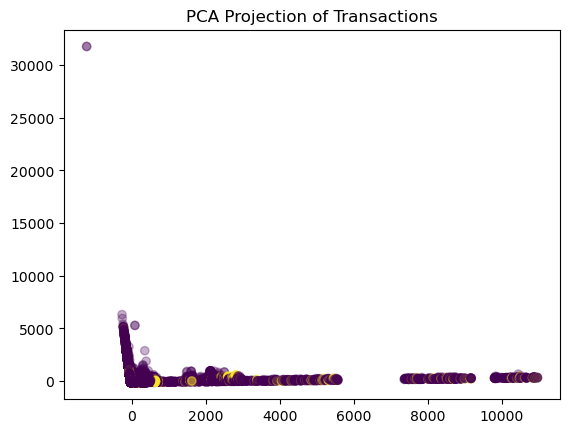

In [28]:
features = ["TransactionAmt"] + [f"C{i}" for i in range(1,15)]
data = df[features].fillna(0)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(data)

plt.scatter(pca_result[:,0], pca_result[:,1], c=df["isFraud"], alpha=0.3)
plt.title("PCA Projection of Transactions")
plt.show()


## Hypothesis Testing

In [29]:
# Email domain mismatch hypothesis
df["email_mismatch"] = df["P_emaildomain"] != df["R_emaildomain"]

table = pd.crosstab(df["email_mismatch"], df["isFraud"])
chi2, p, _, _ = chi2_contingency(table)

print("Email mismatch p-value:", p)


Email mismatch p-value: 0.0


In [30]:
# Device type hypothesis
table = pd.crosstab(df["DeviceType"], df["isFraud"])
chi2, p, _, _ = chi2_contingency(table)

print("Device type p-value:", p)


Device type p-value: 1.3507694124889397e-134


In [31]:
# Temporal hypothesis
hour_table = pd.crosstab(df["hour"], df["isFraud"])
chi2, p, _, _ = chi2_contingency(hour_table)

print("Temporal p-value:", p)


Temporal p-value: 0.0


In [32]:
# Card velocity hypothesis
card_counts = df.groupby("card1").size()
df["card_freq"] = df["card1"].map(card_counts)

df["high_velocity"] = df["card_freq"] > 20

table = pd.crosstab(df["high_velocity"], df["isFraud"])
chi2, p, _, _ = chi2_contingency(table)

print("Card velocity p-value:", p)


Card velocity p-value: 2.142413748340418e-22


## Baseline Model

In [33]:
selected_features = list(top50)

data = df[selected_features + ["isFraud"]].fillna(0)

X = data.drop("isFraud", axis=1)
y = data["isFraud"]


In [34]:
split_index = int(len(df)*0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]


In [35]:
model = lgb.LGBMClassifier(n_estimators=200)
model.fit(X_train, y_train)


[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.093966 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9073
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,200
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


## Model Evaluation

In [36]:
preds = model.predict_proba(X_test)[:,1]

roc = roc_auc_score(y_test, preds)
print("ROC AUC:", roc)


ROC AUC: 0.8944904581395853


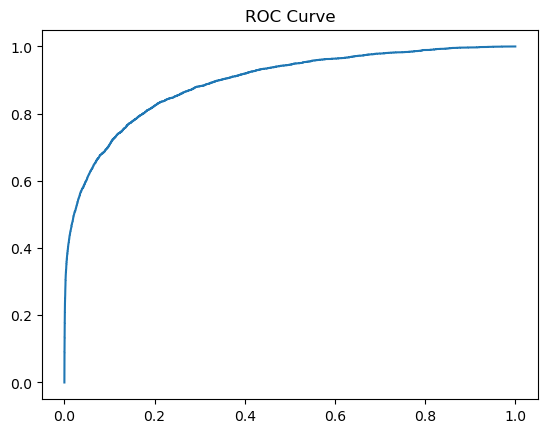

In [37]:
fpr, tpr, _ = roc_curve(y_test, preds)

plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.show()


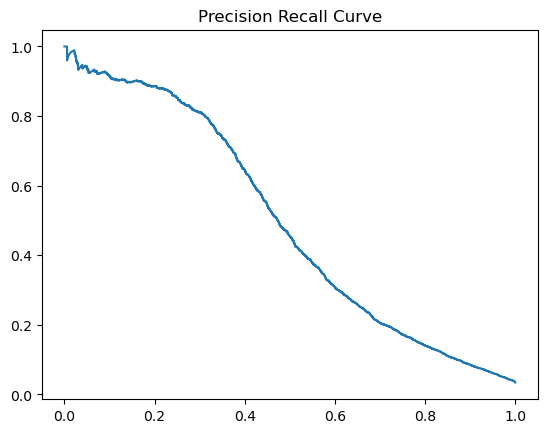

In [38]:
precision, recall, _ = precision_recall_curve(y_test, preds)

plt.plot(recall, precision)
plt.title("Precision Recall Curve")
plt.show()


In [39]:
y_pred = (preds > 0.5).astype(int)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[113578    466]
 [  2672   1392]]
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    114044
           1       0.75      0.34      0.47      4064

    accuracy                           0.97    118108
   macro avg       0.86      0.67      0.73    118108
weighted avg       0.97      0.97      0.97    118108



## Feature Importance

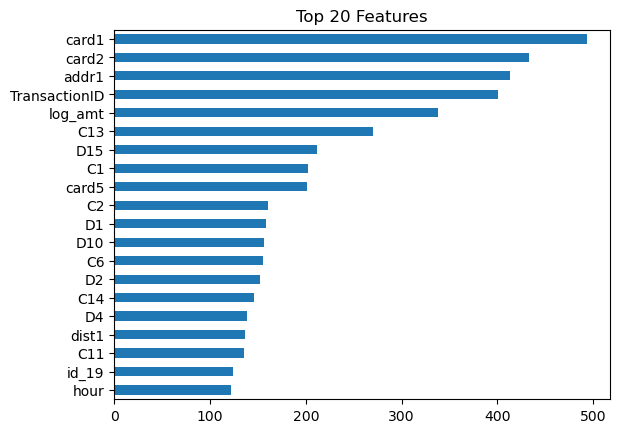

In [40]:
importance = pd.Series(model.feature_importances_, index=X.columns)

importance.sort_values().tail(20).plot(kind="barh")
plt.title("Top 20 Features")
plt.show()
